In [ ]:
# === Cellule 1 : Setup + sélection des 50 cas RSNA équilibrés ===
from pathlib import Path
import sys
import json
import time
import pandas as pd
from tqdm import tqdm

# Path setup
ROOT = Path('..').resolve()
sys.path.append(str(ROOT))

from src.medgemma_inference import medgemma_predict
from src.guardrails import apply_safety_guardrails, validate_prediction
from src.database import insert_run, init_db

# Chargement du CSV RSNA (100 cas)
cases_full = pd.read_csv(ROOT / "data" / "rsna_png" / "rsna_cases.csv")
print(f"📂 {len(cases_full)} cas RSNA disponibles")

# Sélection équilibrée de 50 cas (25 normal + 25 pneumonie)
import random
random.seed(42)
normal = cases_full[cases_full["label"] == "normal"].sample(n=25, random_state=42)
pneumo = cases_full[cases_full["label"] == "suspected_opacity"].sample(n=25, random_state=42)
cases_df = pd.concat([normal, pneumo]).reset_index(drop=True)

print(f"✅ {len(cases_df)} cas sélectionnés")
print(f"   Distribution : {dict(cases_df['label'].value_counts())}")

# SQLite
db_path = ROOT / "eval" / "medical_ai_evidence.sqlite"
init_db(db_path)

# Output dir
out_dir = ROOT / "eval" / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

print(f"⏱️ ETA : 50 cas × ~3 min = ~2h30")
cases_df.head()

✅ 50 cas rechargés depuis medgemma_rsna_baseline_predictions.csv
   Distribution prédictions : {'suspected_opacity': np.int64(38), 'normal': np.int64(12)}
   Distribution vérité       : {'normal': np.int64(25), 'suspected_opacity': np.int64(25)}


,case_id,patientId,label,predicted_class,confidence,image_quality,latency_ms,latency_min,json_valid,error
0,RSNA_014,476fd67f-33e0-47e7-b7d2-5f6e2afe4662,normal,normal,0.8,good,226897,3.78,True,NaN
1,RSNA_040,a304611a-7d97-428b-a09e-26c9d11d4f51,normal,normal,0.8,good,218068,3.63,True,NaN
2,RSNA_031,9bfd4fb6-ed78-41a5-9085-3282cb64fc63,normal,normal,0.8,good,203373,3.39,True,NaN
3,RSNA_046,e73157b2-951b-44c3-8065-87edd9d0fd6f,normal,suspected_opacity,0.6,good,226837,3.78,True,NaN
4,RSNA_018,fd2dbd18-2202-45da-bb4f-466c33583179,normal,normal,0.8,good,199996,3.33,True,NaN


In [2]:
# === Cellule 2 : Run BASELINE MedGemma sur 50 cas RSNA (~2h30) ===
baseline_results = []
baseline_path = out_dir / "medgemma_rsna_baseline_predictions.csv"

print(f"🚀 Lancement du run baseline sur {len(cases_df)} cas RSNA réels...")
print(f"⏱️ ETA estimée : ~{len(cases_df) * 3:.0f} minutes ({len(cases_df) * 3 / 60:.1f} heures)")
print(f"💾 Sauvegarde incrémentale dans : {baseline_path.name}\n")

for _, case in tqdm(cases_df.iterrows(), total=len(cases_df), desc="RSNA-baseline"):
    image_path = ROOT / case["image_path"]

    try:
        t_start = time.perf_counter()
        pred = apply_safety_guardrails(medgemma_predict(image_path, mode="baseline"))
        t_end = time.perf_counter()
        latency = int((t_end - t_start) * 1000)
        valid, errors = validate_prediction(pred)
        error_str = ""
    except Exception as e:
        pred = {"predicted_class": "uncertain", "confidence": 0.0,
                "image_quality": "poor", "visual_evidence": [],
                "justification": "ERROR", "limitations": [str(e)[:200]]}
        latency = -1
        valid = False
        error_str = str(e)[:200]

    insert_run(db_path, case["case_id"], str(image_path), pred)

    baseline_results.append({
        "case_id": case["case_id"],
        "patientId": case.get("patientId", ""),
        "label": case["label"],
        "predicted_class": pred["predicted_class"],
        "confidence": pred.get("confidence", 0),
        "image_quality": pred.get("image_quality", "?"),
        "latency_ms": latency,
        "latency_min": round(latency / 60000, 2),
        "json_valid": valid,
        "error": error_str,
    })

    # 🔒 SAUVEGARDE INCRÉMENTALE après chaque cas
    pd.DataFrame(baseline_results).to_csv(baseline_path, index=False, encoding="utf-8")

baseline_df = pd.DataFrame(baseline_results)
print(f"\n✅ Run baseline RSNA terminé sur {len(baseline_df)} cas")
print(f"   • Latence totale : {baseline_df['latency_min'].sum():.1f} min")
print(f"   • Latence moyenne : {baseline_df['latency_min'].mean():.1f} min/image")
print(f"   • Erreurs : {(baseline_df['error'] != '').sum()}")
print(f"   • JSON valides : {baseline_df['json_valid'].sum()}/{len(baseline_df)}")

baseline_df.head(10)

🚀 Lancement du run baseline sur 50 cas RSNA réels...
⏱️ ETA estimée : ~150 minutes (2.5 heures)
💾 Sauvegarde incrémentale dans : medgemma_rsna_baseline_predictions.csv



RSNA-baseline:   0%|          | 0/50 [00:00<?, ?it/s]

⏳ Chargement de google/medgemma-4b-it (1ère fois = ~4 Go à télécharger)...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

[transformers] Deprecated: `processor.image_token` will switch from returning `tokenizer.image_token` to `tokenizer.boi_token` in v5.11.


✅ MedGemma chargé en 22.1 s


RSNA-baseline: 100%|██████████| 50/50 [2:32:40<00:00, 183.21s/it]  


✅ Run baseline RSNA terminé sur 50 cas
   • Latence totale : 152.7 min
   • Latence moyenne : 3.1 min/image
   • Erreurs : 0
   • JSON valides : 50/50


,case_id,patientId,label,predicted_class,confidence,image_quality,latency_ms,latency_min,json_valid,error
0,RSNA_014,476fd67f-33e0-47e7-b7d2-5f6e2afe4662,normal,normal,0.8,good,226897,3.78,True,
1,RSNA_040,a304611a-7d97-428b-a09e-26c9d11d4f51,normal,normal,0.8,good,218068,3.63,True,
2,RSNA_031,9bfd4fb6-ed78-41a5-9085-3282cb64fc63,normal,normal,0.8,good,203373,3.39,True,
3,RSNA_046,e73157b2-951b-44c3-8065-87edd9d0fd6f,normal,suspected_opacity,0.6,good,226837,3.78,True,
4,RSNA_018,fd2dbd18-2202-45da-bb4f-466c33583179,normal,normal,0.8,good,199996,3.33,True,
5,RSNA_049,42a2589c-761a-41e0-b7a4-331214140b5d,normal,normal,0.8,good,218603,3.64,True,
6,RSNA_027,85cee2f7-9628-4c61-a51f-f7be52f5c5c9,normal,normal,0.8,good,161695,2.69,True,
7,RSNA_026,f92e409f-ade8-48a5-84db-55fa498ec3c3,normal,suspected_opacity,0.6,good,150119,2.50,True,
8,RSNA_033,5c015feb-cfd1-4ce2-9b95-eb9689c7eb0a,normal,suspected_opacity,0.4,good,158126,2.64,True,
9,RSNA_020,ef6ccb09-61d9-4eba-90e6-0f35fdc02266,normal,suspected_opacity,0.6,good,149328,2.49,True,


In [4]:
# === Cellule 1 (REPRISE) : Re-setup après redémarrage ===
from pathlib import Path
import sys
import json
import time
import pandas as pd
from tqdm import tqdm

# Path setup
ROOT = Path('..').resolve()
sys.path.append(str(ROOT))

from src.guardrails import validate_prediction
from src.database import insert_run, init_db
# Note : on ne réimporte PAS medgemma_predict, pas besoin de re-charger MedGemma

# 🔄 Rechargement de baseline_df depuis le CSV sauvegardé
out_dir = ROOT / "eval" / "outputs"
baseline_path = out_dir / "medgemma_rsna_baseline_predictions.csv"

baseline_df = pd.read_csv(baseline_path)
print(f"✅ {len(baseline_df)} cas rechargés depuis {baseline_path.name}")
print(f"   Distribution prédictions : {dict(baseline_df['predicted_class'].value_counts())}")
print(f"   Distribution vérité       : {dict(baseline_df['label'].value_counts())}")

baseline_df.head()

✅ 50 cas rechargés depuis medgemma_rsna_baseline_predictions.csv
   Distribution prédictions : {'suspected_opacity': np.int64(38), 'normal': np.int64(12)}
   Distribution vérité       : {'normal': np.int64(25), 'suspected_opacity': np.int64(25)}


,case_id,patientId,label,predicted_class,confidence,image_quality,latency_ms,latency_min,json_valid,error
0,RSNA_014,476fd67f-33e0-47e7-b7d2-5f6e2afe4662,normal,normal,0.8,good,226897,3.78,True,NaN
1,RSNA_040,a304611a-7d97-428b-a09e-26c9d11d4f51,normal,normal,0.8,good,218068,3.63,True,NaN
2,RSNA_031,9bfd4fb6-ed78-41a5-9085-3282cb64fc63,normal,normal,0.8,good,203373,3.39,True,NaN
3,RSNA_046,e73157b2-951b-44c3-8065-87edd9d0fd6f,normal,suspected_opacity,0.6,good,226837,3.78,True,NaN
4,RSNA_018,fd2dbd18-2202-45da-bb4f-466c33583179,normal,normal,0.8,good,199996,3.33,True,NaN


In [5]:
# === Cellule 3 : Métriques globales sur 50 cas RSNA ===
from src.metrics import accuracy, macro_f1

y_true = baseline_df["label"].tolist()
y_pred = baseline_df["predicted_class"].tolist()
valid_classes = {"normal", "suspected_opacity", "uncertain"}
hallucinations = baseline_df[~baseline_df["predicted_class"].isin(valid_classes)]

metrics = {
    "mode": "medgemma_baseline_rsna",
    "dataset": "RSNA Pneumonia 2018",
    "n_cases": len(baseline_df),
    "accuracy": round(accuracy(y_true, y_pred), 4),
    "macro_f1": round(macro_f1(y_true, y_pred), 4),
    "json_valid_rate": round(baseline_df["json_valid"].mean(), 4),
    "uncertain_rate": round((baseline_df["predicted_class"] == "uncertain").mean(), 4),
    "latency_min_median": round(baseline_df["latency_ms"].median() / 60000, 2),
    "hallucination_count": len(hallucinations),
}

print("📊 Métriques MedGemma baseline (50 cas RSNA) :")
print(json.dumps(metrics, indent=2))

# Vérification des cibles du brief
print("\n🎯 Critères du brief :")
checks = [
    ("Accuracy ≥ 0.70", metrics["accuracy"] >= 0.70, metrics["accuracy"], 0.70),
    ("Macro-F1 ≥ 0.68", metrics["macro_f1"] >= 0.68, metrics["macro_f1"], 0.68),
    ("JSON valides ≥ 95%", metrics["json_valid_rate"] >= 0.95, metrics["json_valid_rate"], 0.95),
    ("Hallucinations = 0", metrics["hallucination_count"] == 0, metrics["hallucination_count"], 0),
]
for label, ok, val, target in checks:
    icon = "✅" if ok else "⚠️"
    print(f"  {icon} {label} : {val} (cible {target})")

# Sauvegarde
metrics_path = out_dir / "medgemma_rsna_baseline_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
print(f"\n💾 Sauvé dans : {metrics_path.name}")

📊 Métriques MedGemma baseline (50 cas RSNA) :
{
  "mode": "medgemma_baseline_rsna",
  "dataset": "RSNA Pneumonia 2018",
  "n_cases": 50,
  "accuracy": 0.74,
  "macro_f1": 0.4808,
  "json_valid_rate": 1.0,
  "uncertain_rate": 0.0,
  "latency_min_median": 2.77,
  "hallucination_count": 0
}

🎯 Critères du brief :
  ✅ Accuracy ≥ 0.70 : 0.74 (cible 0.7)
  ⚠️ Macro-F1 ≥ 0.68 : 0.4808 (cible 0.68)
  ✅ JSON valides ≥ 95% : 1.0 (cible 0.95)
  ✅ Hallucinations = 0 : 0 (cible 0)

💾 Sauvé dans : medgemma_rsna_baseline_metrics.json


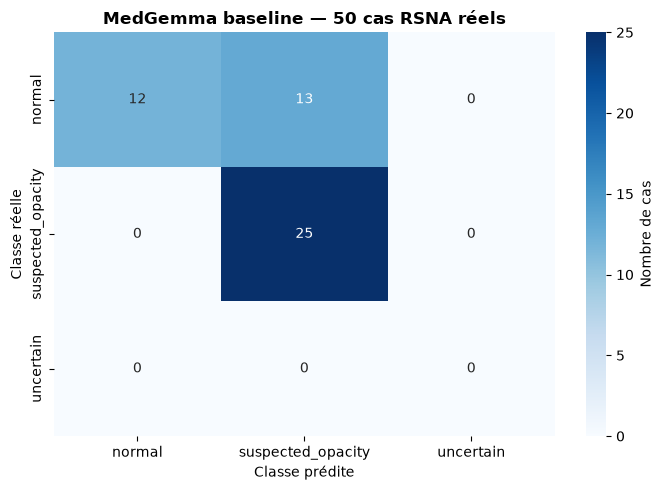


📊 Métriques détaillées par classe :


,classe,support,precision,recall,f1
0,normal,25,1.000,0.48,0.649
1,suspected_opacity,25,0.658,1.00,0.794
2,uncertain,0,0.000,0.00,0.000


In [6]:
# === Cellule 4 : Matrice de confusion + métriques par classe ===
import matplotlib.pyplot as plt
import seaborn as sns

classes = ["normal", "suspected_opacity", "uncertain"]
cm = pd.DataFrame(0, index=classes, columns=classes, dtype=int)
for t, p in zip(y_true, y_pred):
    cm.loc[t, p] += 1

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            cbar_kws={"label": "Nombre de cas"})
ax.set_title("MedGemma baseline — 50 cas RSNA réels", fontweight="bold")
ax.set_xlabel("Classe prédite")
ax.set_ylabel("Classe réelle")
plt.tight_layout()
plt.show()

# Métriques par classe
print("\n📊 Métriques détaillées par classe :")
per_class = []
for c in classes:
    tp = sum((t == c) and (p == c) for t, p in zip(y_true, y_pred))
    fp = sum((t != c) and (p == c) for t, p in zip(y_true, y_pred))
    fn = sum((t == c) and (p != c) for t, p in zip(y_true, y_pred))
    support = sum(t == c for t in y_true)
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    per_class.append({"classe": c, "support": support,
                      "precision": round(precision, 3),
                      "recall": round(recall, 3),
                      "f1": round(f1, 3)})

per_class_df = pd.DataFrame(per_class)
per_class_df

In [7]:
# === Cellule 5 : Sauvegarde des artefacts S4 baseline RSNA ===
metrics_extended = {
    **metrics,
    "per_class": per_class_df.to_dict(orient="records"),
    "confusion_matrix": cm.to_dict(),
    "findings": {
        "main_observation": "MedGemma surclasse en suspected_opacity (13/25 normal → susp_op)",
        "clinical_interpretation": "Prudence radiologique : préférer FP à FN",
        "uncertainty_rule_triggered": False,
        "next_step": "Tester mode improved avec seuil 0.60 strict",
    }
}

metrics_path = out_dir / "medgemma_rsna_baseline_metrics_full.json"
metrics_path.write_text(json.dumps(metrics_extended, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"💾 Métriques complètes sauvées dans : {metrics_path.name}")

💾 Métriques complètes sauvées dans : medgemma_rsna_baseline_metrics_full.json
